In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")

import sirf.STIR as spect
from simind_python_connector import StirSimindAdaptor
import stir_simind_utils as utils
spect.set_verbosity(0)

demo1_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1") 
demo2_path = Path("/home/jovyan/sirf-demo/SIRF-demo-2")

sim_dir = demo1_path / "simind_data" / "lu177_128"
input_dir = sim_dir / "input"
tomo_dir = sim_dir / "tomo"
mc_dir = demo2_path / "mc_scatter"
mc_dir.mkdir(parents=True, exist_ok=True)

icf_osem = 109.264725
icf_osem_rm = 109.16247
icf_osem_mc = 123.46838
icf_osem_rm_mc = 122.46166

INFO: Note: NumExpr detected 24 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO: NumExpr defaulting to 16 threads.


In [2]:
# Change these paths if required for the measured dataset
pp_path = tomo_dir / "lu177_simulation_em_noisy.hs"
tew_path = tomo_dir / "lu177_simulation_tew_scatter.hs"

ctac_path = input_dir / "nema_lu_ctac.hv"

acq_em_data = spect.AcquisitionData(str(pp_path))
acq_tew_data = spect.AcquisitionData(str(tew_path))
attenuation_map = spect.ImageData(str(ctac_path))

matrix_size = (128,) * 3
voxel_size = (4.42,) * 3

initial_image = spect.ImageData(acq_em_data)
initial_image.initialise(matrix_size, vsize=voxel_size)
initial_image.set_modality("NM")
initial_image.fill(1)

# STIR attenuation-map orientation
attenuation_map_stir = attenuation_map.clone()
attenuation_map_stir.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

In [4]:
#sigma_0 = 2.35598  # mm
#slope = 0.01771

acq_model_matrix = spect.SPECTUBMatrix()
acq_model_matrix.set_keep_all_views_in_cache(True)
acq_model_matrix.set_attenuation_image(attenuation_map_stir)
#acq_model_matrix.set_resolution_model(float(sigma_0), float(slope), full_3D=False)

acq_model = spect.AcquisitionModelUsingMatrix(
    acq_model_matrix
)
acq_model.set_up(acq_em_data, initial_image)
acq_model.set_additive_term(acq_tew_data)

In [5]:
subiterations = 60
subsets = 12

obj_fun = spect.make_Poisson_loglikelihood(acq_em_data)
obj_fun.set_acquisition_model(acq_model)

recon = spect.OSMAPOSLReconstructor()
recon.set_num_subiterations(subiterations)
recon.set_num_subsets(subsets)
recon.set_objective_function(obj_fun)

recon_image = initial_image.clone()

recon.set_up(recon_image)
recon.reconstruct(recon_image)

recon_image.write(str(mc_dir / "initial_reconstruction"))

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Initial OSEM reconstruction'}>,
        <Axes: title={'center': 'Source used for SIMIND'}>,
        <Axes: title={'center': 'Ground Truth'}>], dtype=object))

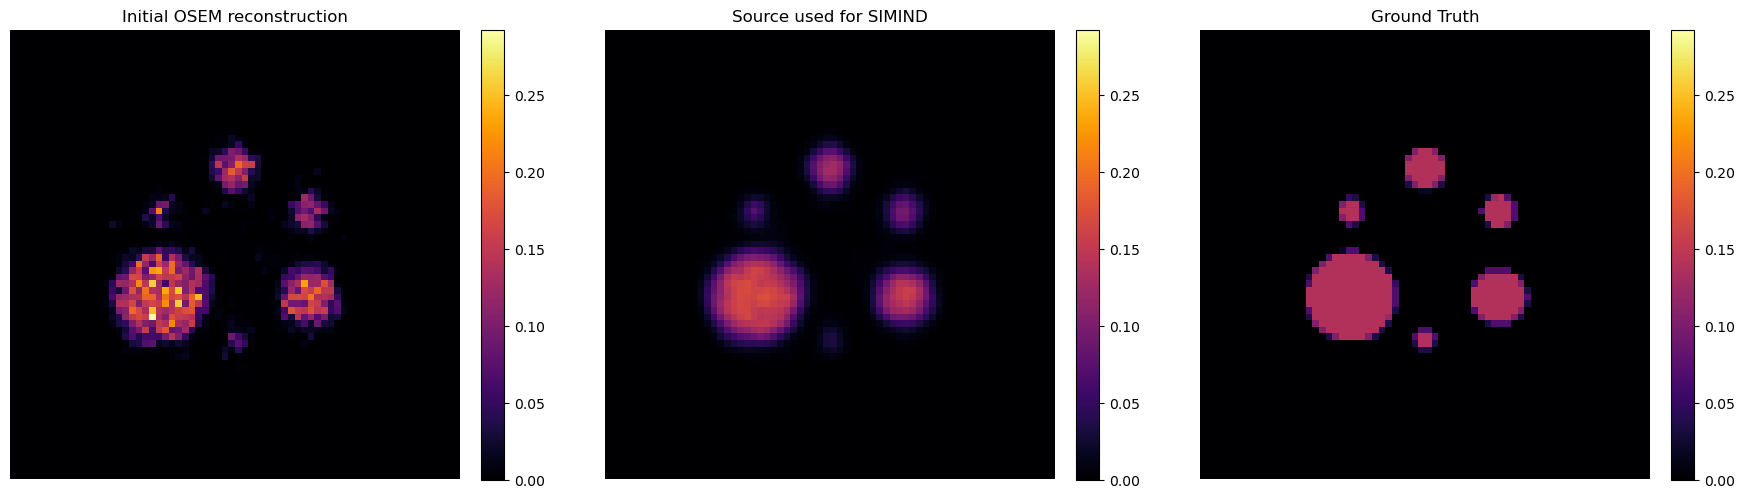

In [9]:
gt_image = spect.ImageData(str(demo1_path / "simind_data" / "lu177_128" / "input" / "nema_lu_act.hv"))
initial_reconstruction = spect.ImageData(str(mc_dir / "initial_reconstruction.hv")) / icf_osem

source_for_simind = initial_reconstruction.clone()
sigma = 9.0
gaussian_filter = spect.SeparableGaussianImageFilter()
gaussian_filter.set_fwhms((sigma, sigma, sigma))
gaussian_filter.apply(source_for_simind)

source_arr = source_for_simind.as_array()
source_for_simind.fill(source_arr)

source_for_simind.write(str(mc_dir / "source_for_simind"))

idx = (55, slice(30, 98), slice(30, 98))

vmax = max(
    np.max(initial_reconstruction.as_array()[idx]),
    np.max(source_for_simind.as_array()[idx]),
)

utils.display_arr(
    arr_3d=[
        initial_reconstruction.as_array(),
        source_for_simind.as_array(),
        gt_image.as_array()
    ],
    idx=idx,
    vmax=[vmax, vmax, vmax],
    titles=[
        "Initial OSEM reconstruction",
        "Source used for SIMIND",
        "Ground Truth"
    ]
)

## Configure the SIMIND Monte Carlo scatter simulation

SIMIND is now configured using the reconstructed activity estimate as the **source distribution** and the attenuation map as the object model.

For Lu-177, the principal imaging window is centred on the **208 keV emission**. The Monte Carlo simulation models photon transport through the phantom and detector system, including scattering events.

A low `photon_multiplier` is used during the workshop to reduce runtime. For quantitative work, substantially higher simulation statistics would normally be required.

In [10]:
# Lu-177 photopeak window
window_lower = [187.2]   # keV
window_upper = [228.8]   # keV
scatter_orders = [0]
time_per_proj = 10 #sec

config_file = "/home/jovyan/sirf-demo/.packages/Discovery670_lu177.yaml"

output_dir = mc_dir / "simind_data_it1"
output_dir.mkdir(parents=True, exist_ok=True)

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_dir),
    output_prefix="lu177_mc_scatter",
    photon_multiplier=0.05,
)

simind.set_source(source_for_simind)
simind.set_mu_map(attenuation_map)

simind.add_config_value(25, np.sum(source_for_simind.as_array()) * time_per_proj)

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)

simind.add_runtime_switch("FI", "lu177")
simind.add_runtime_switch("CC", "ge-megp")
simind.add_runtime_switch("RR", 12345)

outputs = simind.run()

# Inspect the returned output mapping in case filenames differ
print(outputs)

INFO: Running SIMIND: simind lu177_mc_scatter lu177_mc_scatter /NN:0.05/FI:lu177/CC:ge-megp/RR:12345/PX:0.4420000076293945


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_mc_scatter  
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_mc_scatter  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_mc_scatter_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_mc_scatter_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 208          lu177     PhotonsPerProj....: 42448          
 EnergyResolution...: 12           Spectra   Activity..........: 2936.6         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 312          x-rays    Distance to det...: 17.022         
 LowerEneWindowTresh: 104          Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_air_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_sca_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_sca_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_sca_w2.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_sca_w2.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it1/lu177_mc_scatter_tot_w1.

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 1                      CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 128                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 128                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 15662.46624    
 NN ScalingFactor...: 0.05                   Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

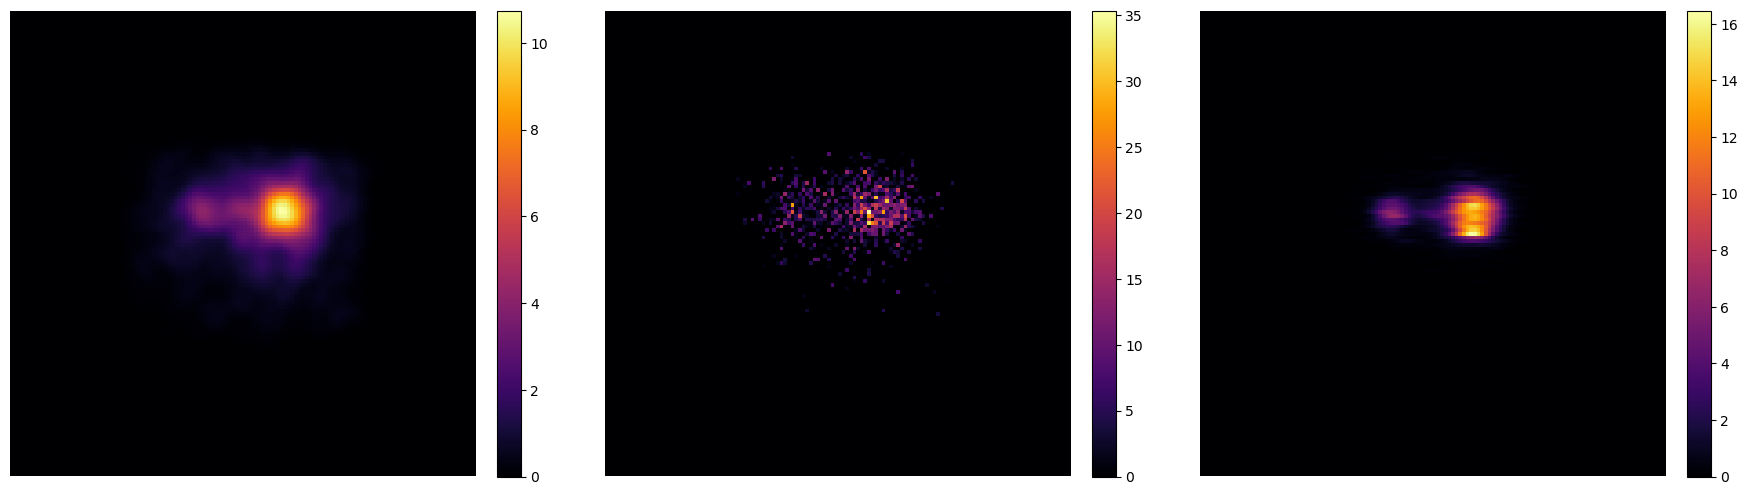

In [11]:
tomo_sim_em = spect.AcquisitionData(str(output_dir / "lu177_mc_scatter_tot_w1.hs"))
tomo_sca = spect.AcquisitionData(str(output_dir / "lu177_mc_scatter_sca_w1.hs"))
tomo_sca_scaled = utils.scale_mc_scatter_binwise(
    mc_scatter=tomo_sca,
    measured_photopeak=acq_em_data,
    simulated_photopeak=tomo_sim_em
)
tomo_sca_smoothed = utils.smooth_acquisition_data(
    acq_data=tomo_sca_scaled,
    sigma=2.0
)

utils.display_arr(
    arr_3d=[acq_tew_data.as_array()[0], tomo_sca.as_array()[0], tomo_sca_smoothed.as_array()[0]],
    idx=(slice(None), 60, slice(None))
)

## Load the Monte Carlo scatter estimate

The SIMIND **scatter-only projection data** are loaded as a SIRF/STIR `AcquisitionData` object.

The exact output filename depends on the connector version and configuration. The standard SIMIND connector output uses `_sca_w1.hs` for the scatter contribution in the first energy window.


In [12]:
recon_dir = mc_dir / "recons" / "osem_mc1"
recon_dir.mkdir(parents=True, exist_ok=True)
acq_model_matrix = spect.SPECTUBMatrix()
acq_model_matrix.set_keep_all_views_in_cache(True)
acq_model_matrix.set_attenuation_image(attenuation_map_stir)
#acq_model_matrix.set_resolution_model(
#    float(sigma_0),
#    float(slope),
#    full_3D=False
#)

acq_model = spect.AcquisitionModelUsingMatrix(
    acq_model_matrix
)

acq_model.set_additive_term(tomo_sca_smoothed)
acq_model.set_up(acq_em_data, initial_image)

subiterations = 100
subsets = 2
save_interval = 10
name_prefix = "lu177_mc_recon"

obj_fun = spect.make_Poisson_loglikelihood(acq_em_data)
obj_fun.set_acquisition_model(acq_model)

recon = spect.OSMAPOSLReconstructor()
recon.set_num_subiterations(subiterations)

recon.set_save_interval(save_interval)
recon.enable_output()
recon.set_output_filename_prefix(str(recon_dir / name_prefix))
recon.set_num_subsets(subsets)
recon.set_objective_function(obj_fun)

recon_image = initial_image.clone()

recon.set_up(recon_image)
recon.reconstruct(recon_image)

## Load the conventional TEW-corrected reconstruction

For comparison, we also use the reconstruction obtained with **triple-energy-window (TEW) scatter correction**.

This provides three reconstruction conditions:

1. **No scatter correction**
2. **SIMIND Monte Carlo scatter correction**
3. **TEW scatter correction**

In [13]:
mc_reconstruction = spect.ImageData(str(recon_dir / "lu177_mc_recon_100.hv")) / icf_osem

tew_recon_path = (
    demo1_path / "simind_data/lu177_128/recons/osem/lu177_sim_osem_100.hv"
)

# Replace the path above with the reconstruction generated from the
# TEW-corrected projection data if stored separately.
tew_reconstruction = spect.ImageData(str(tew_recon_path)) / icf_osem

## Compare the reconstructed images

The three reconstruction strategies are displayed using the same image region and intensity scale.

This comparison illustrates the effect of the scatter estimate on reconstructed contrast and background activity. A visual comparison is useful, but quantitative assessment should also be performed using known phantom regions, for example recovery coefficients or activity-concentration bias.

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'OSEM - no scatter correction'}>,
        <Axes: title={'center': 'OSEM - SIMIND scatter correction'}>,
        <Axes: title={'center': 'OSEM - TEW scatter correction'}>],
       dtype=object))

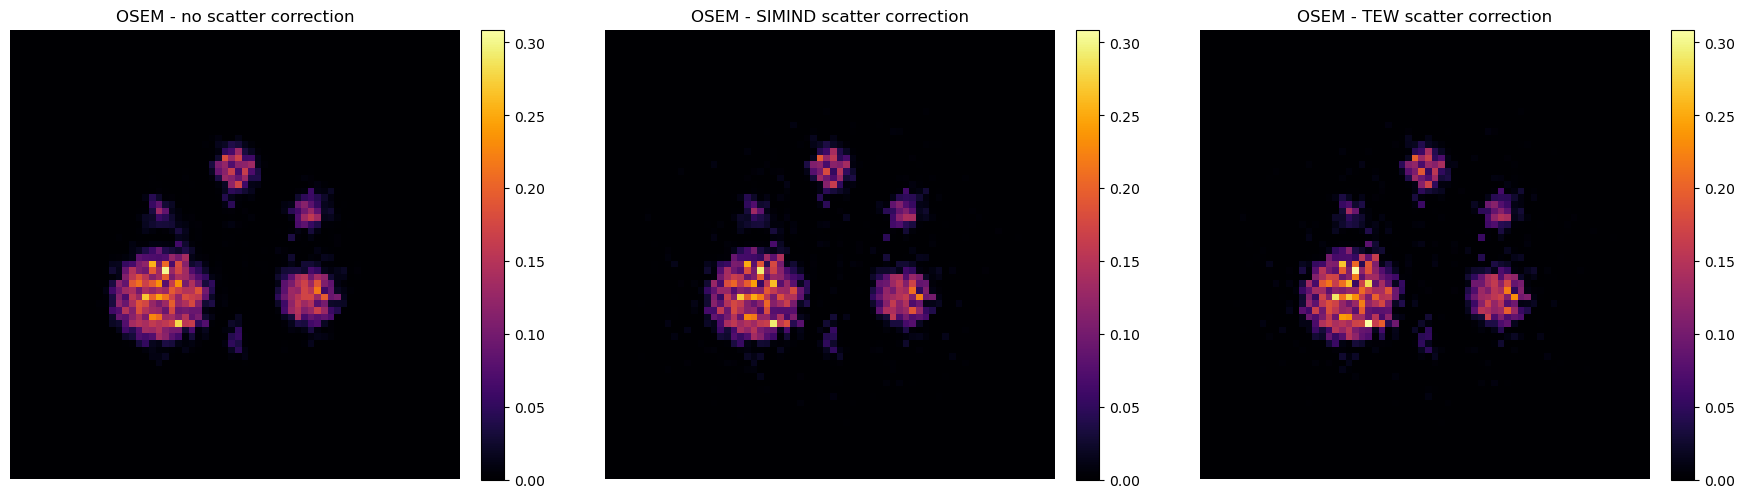

In [14]:
idx = (56, slice(30, 98), slice(30, 98))

recon_arrays = [
    initial_reconstruction.as_array(),
    mc_reconstruction.as_array(),
    tew_reconstruction.as_array(),
]

vmax = max(np.max(arr[idx]) for arr in recon_arrays)

utils.display_arr(
    arr_3d=recon_arrays,
    idx=idx,
    vmax=[vmax] * 3,
    titles=[
        "OSEM - no scatter correction",
        "OSEM - SIMIND scatter correction",
        "OSEM - TEW scatter correction"
    ]
)

## Summary

This notebook demonstrates a **reconstruction-driven Monte Carlo scatter-correction workflow**:

**measured projections → initial reconstruction → SIMIND scatter simulation → additive scatter model → final reconstruction**

Unlike DEW/TEW methods, which estimate scatter from neighbouring energy windows, the Monte Carlo approach estimates scatter by explicitly modelling photon transport through the reconstructed source and attenuation distribution.

### Points to consider

- The quality of the Monte Carlo scatter estimate depends on the accuracy of the **initial activity estimate** and **attenuation map**.
- Monte Carlo noise should be sufficiently low that it does not introduce additional structure into the reconstruction. Alternatively, denoise the estimate.
- Camera, collimator, energy-resolution, acquisition-geometry, and radionuclide settings should match the measured acquisition.
- Monte Carlo scatter correction is substantially more computationally demanding than energy-window methods, but provides a more explicit physical model of scatter.

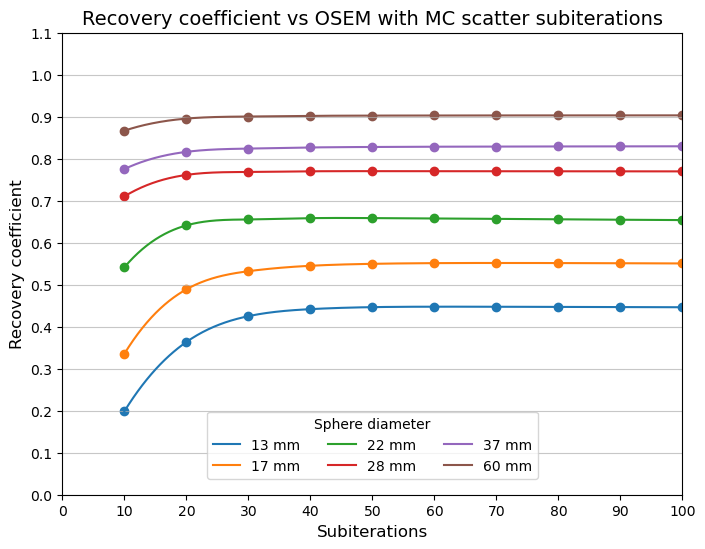

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Lu-177 Ground Truth'}>,
        <Axes: title={'center': 'Lu-177 OSEM MC reconstruction (sub=100)'}>,
        <Axes: title={'center': 'Difference Image'}>], dtype=object))

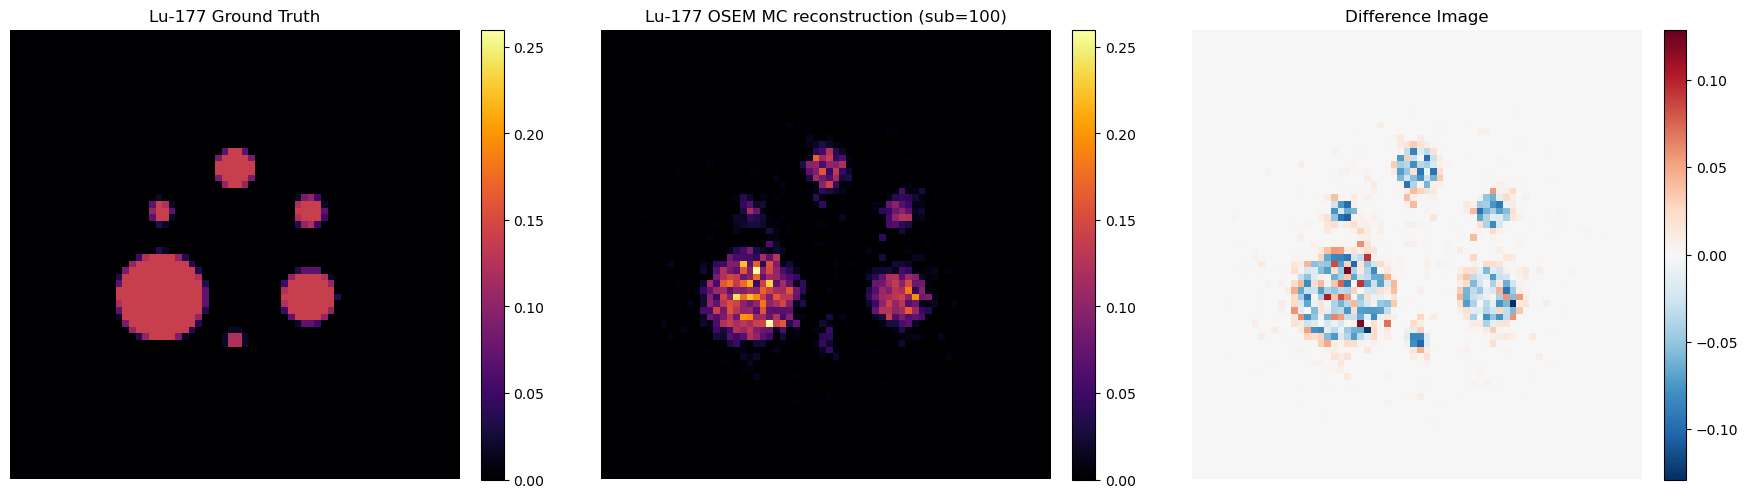

In [16]:
diametre_mm = [13, 17, 22, 28, 37, 60]

recon_prefix = "lu177_mc_recon"

gt_dir = demo1_path / "simind_data" / "lu177_128" / "input"
recon_dir = demo2_path / "mc_scatter" / "recons" / "osem_mc1"

# Load source image
nema_act_arr = spect.ImageData(
    str(gt_dir / "nema_lu_act.hv")
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(gt_dir / "masks_lu.npz")
)

rc_data = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    icf=icf_osem,
    verbose=False
)

utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title=f"Recovery coefficient vs OSEM with MC scatter subiterations",
    ylim=(0,1.1)
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = recon_dict[str(subit)] / icf_osem_mc

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit, recon_subit-nema_act_arr],
    idx=idx,
    vmax=[vmax, vmax, np.max(np.abs(nema_act_arr[idx] - recon_subit[idx]))],
    titles=[f"Lu-177 Ground Truth", 
        f"Lu-177 OSEM MC reconstruction (sub={subit})",
        "Difference Image"
        ],
    cmap=["inferno", "inferno", "RdBu_r"]
)

In [17]:
# Change these paths if required for the measured dataset
pp_path = tomo_dir / "lu177_simulation_em_noisy.hs"
mc_sca_path = output_dir / "lu177_mc_scatter_sca_w1.hs"

ctac_path = input_dir / "nema_lu_ctac.hv"

acq_em_data = spect.AcquisitionData(str(pp_path))
acq_sca_mc_data = spect.AcquisitionData(str(mc_sca_path))
attenuation_map = spect.ImageData(str(ctac_path))

matrix_size = (128,) * 3
voxel_size = (4.42,) * 3

initial_image = spect.ImageData(acq_em_data)
initial_image.initialise(matrix_size, vsize=voxel_size)
initial_image.set_modality("NM")
initial_image.fill(1)

# STIR attenuation-map orientation
attenuation_map_stir = attenuation_map.clone()
attenuation_map_stir.fill(
    np.flip(attenuation_map.as_array(), axis=2)
)

In [18]:
#sigma_0 = 2.35598  # mm
#slope = 0.01771

acq_model_matrix = spect.SPECTUBMatrix()
acq_model_matrix.set_keep_all_views_in_cache(True)
acq_model_matrix.set_attenuation_image(attenuation_map_stir)
#acq_model_matrix.set_resolution_model(float(sigma_0), float(slope), full_3D=False)

acq_model = spect.AcquisitionModelUsingMatrix(
    acq_model_matrix
)
acq_model.set_up(acq_em_data, initial_image)
acq_model.set_additive_term(acq_sca_mc_data)

In [18]:
subiterations = 60
subsets = 12

obj_fun = spect.make_Poisson_loglikelihood(acq_em_data)
obj_fun.set_acquisition_model(acq_model)

recon = spect.OSMAPOSLReconstructor()
recon.set_num_subiterations(subiterations)
recon.set_num_subsets(subsets)
recon.set_objective_function(obj_fun)

recon_image = initial_image.clone()

recon.set_up(recon_image)
recon.reconstruct(recon_image)

recon_image.write(str(mc_dir / "mc_estimate_recon1"))

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'OSEM reconstruction after MC correction 1'}>,
        <Axes: title={'center': 'Source used for SIMIND'}>,
        <Axes: title={'center': 'Ground Truth'}>], dtype=object))

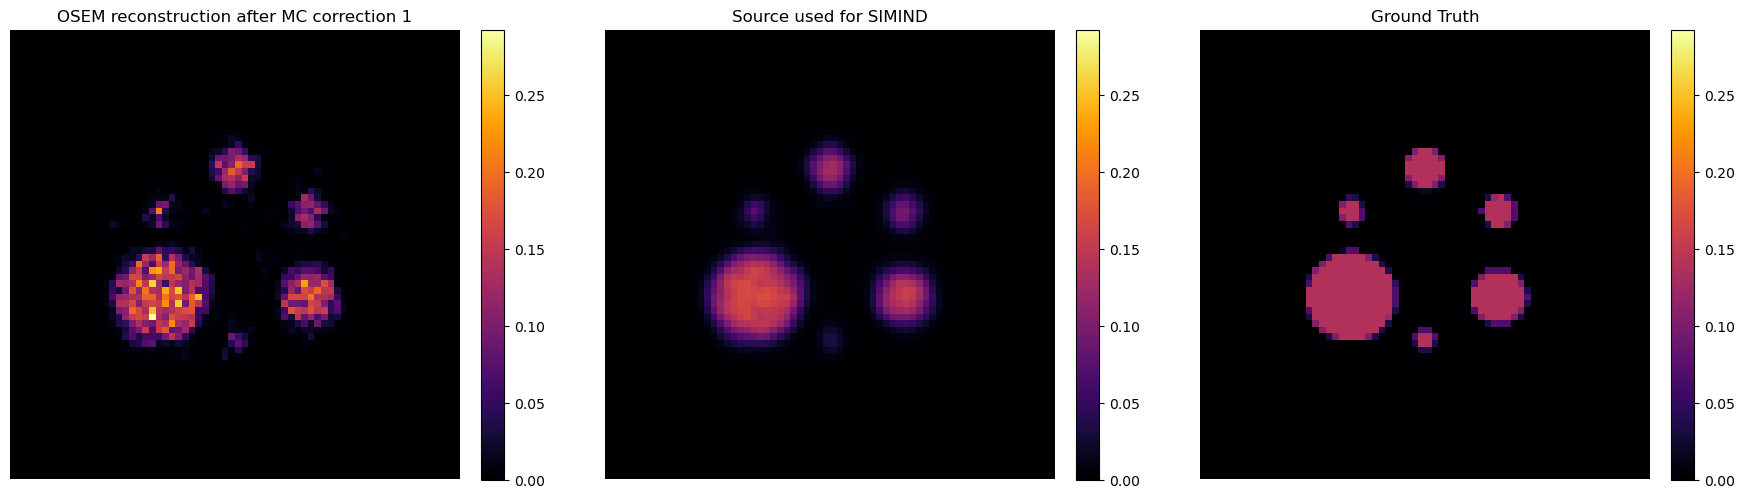

In [19]:
gt_image = spect.ImageData(str(demo1_path / "simind_data" / "lu177_128" / "input" / "nema_lu_act.hv"))
mc_est_recon1 = spect.ImageData(str(mc_dir / "mc_estimate_recon1.hv")) / icf_osem

source_for_simind = initial_reconstruction.clone()

gaussian_filter = spect.SeparableGaussianImageFilter()
gaussian_filter.set_fwhms((9, 9, 9))
gaussian_filter.apply(source_for_simind)

source_for_simind.write(str(mc_dir / "source_for_simind1"))

idx = (55, slice(30, 98), slice(30, 98))

vmax = max(
    np.max(initial_reconstruction.as_array()[idx]),
    np.max(source_for_simind.as_array()[idx]),
)

utils.display_arr(
    arr_3d=[
        initial_reconstruction.as_array(),
        source_for_simind.as_array(),
        gt_image.as_array()
    ],
    idx=idx,
    vmax=[vmax, vmax, vmax],
    titles=[
        "OSEM reconstruction after MC correction 1",
        "Source used for SIMIND",
        "Ground Truth"
    ]
)

In [20]:
# Lu-177 photopeak window
window_lower = [187.2]   # keV
window_upper = [228.8]   # keV
scatter_orders = [0]
time_per_proj = 10 #sec

config_file = "/home/jovyan/sirf-demo/.packages/Discovery670_lu177.yaml"

output_dir = mc_dir / "simind_data_it2"
output_dir.mkdir(parents=True, exist_ok=True)

simind = StirSimindAdaptor(
    config_source=str(config_file),
    output_dir=str(output_dir),
    output_prefix="lu177_mc_scatter",
    photon_multiplier=0.05,
)

simind.set_source(source_for_simind)
simind.set_mu_map(attenuation_map)

simind.add_config_value(25, np.sum(source_for_simind.as_array()) * time_per_proj)

simind.set_energy_windows(
    lower_bounds=window_lower,
    upper_bounds=window_upper,
    scatter_orders=scatter_orders,
)

simind.add_runtime_switch("FI", "lu177")
simind.add_runtime_switch("CC", "ge-megp")
simind.add_runtime_switch("RR", 12345)

outputs = simind.run()

# Inspect the returned output mapping in case filenames differ
print(outputs)

INFO: Running SIMIND: simind lu177_mc_scatter lu177_mc_scatter /NN:0.05/FI:lu177/CC:ge-megp/RR:12345/PX:0.4420000076293945


 



              SIMIND Monte Carlo Simulation Program    V8.0  
------------------------------------------------------------------------------
 Phantom S : h2o       Crystal...: nai       InputFile.: lu177_mc_scatter  
 Phantom B : bone      BackScatt.: pmt       OutputFile: lu177_mc_scatter  
 Collimator: pb_sb2    SourceRout: smap      SourceImg.: lu177_mc_scatter_s
 Cover.....: al        ScoreRout.: scattwin  DensityImg: lu177_mc_scatter_d
------------------------------------------------------------------------------
 PhotonEnergy.......: 208          lu177     PhotonsPerProj....: 42448          
 EnergyResolution...: 12           Spectra   Activity..........: 2936.6         
 MaxScatterOrder....: 3            ge-megp   DetectorLenght....: 20             
 DetectorWidth......: 27           SPECT     DetectorHeight....: 0.9525         
 UpperEneWindowTresh: 312          x-rays    Distance to det...: 17.022         
 LowerEneWindowTresh: 104          Random    ShiftSource X.....: 0

INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it2/lu177_mc_scatter_air_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it2/lu177_mc_scatter_air_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it2/lu177_mc_scatter_sca_w1.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it2/lu177_mc_scatter_sca_w1.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it2/lu177_mc_scatter_sca_w2.h00 to /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it2/lu177_mc_scatter_sca_w2.hs
INFO: Converted 120 radii from orbit file lu177_mc_scatter.cor
INFO: Successfully converted /home/jovyan/sirf-demo/SIRF-demo-2/mc_scatter/simind_data_it2/lu177_mc_scatter_tot_w1.

------------------------------------------------------------------------------
 GENERAL DATA
 keV/channel........: 1                      CutoffEnergy......: 0              
 Photons/Bq.........: 0.2264                 StartingAngle.....: 0              
 CameraOffset X.....: 0                      CoverThickness....: 0.1            
 CameraOffset Y.....: 0                      BackscatterThickn.: 0              
 MatrixSize I.......: 128                    IntrinsicResolut..: 0.55           
 MatrixSize J.......: 128                    AcceptanceAngle...: 4.02754        
 Emission type......: 2                      Initial Weight....: 15662.46624    
 NN ScalingFactor...: 0.05                   Energy Channels...: 512            
                                                                              
 SPECT DATA
 RotationMode.......: 360                    Nr of Projections.: 120            
 RotationAngle......: 3                      Projection.[start]: 1              
 Orbit

Global scale factor beta = 0.8689
SF MC raw:    0.37956494
SF MC global: 0.3298181
SF MC bin:    0.23226504


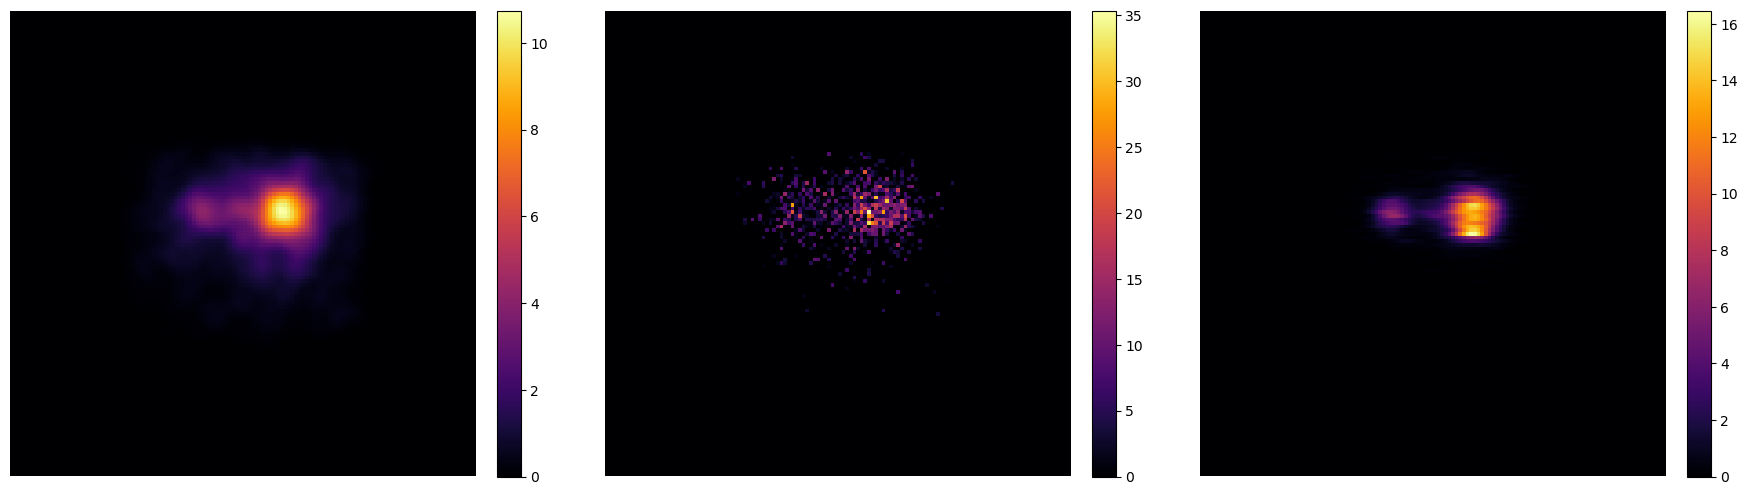

In [30]:
tomo_sim_em = spect.AcquisitionData(str(output_dir / "lu177_mc_scatter_tot_w1.hs"))
tomo_sca = spect.AcquisitionData(str(output_dir / "lu177_mc_scatter_sca_w1.hs"))
tomo_sca_scaled = utils.scale_mc_scatter_binwise(
    mc_scatter=tomo_sca,
    measured_photopeak=acq_em_data,
    simulated_photopeak=tomo_sim_em
)
tomo_sca_smoothed = utils.smooth_acquisition_data(
    acq_data=tomo_sca_scaled,
    sigma=2.0
)

utils.display_arr(
    arr_3d=[acq_tew_data.as_array()[0], tomo_sca.as_array()[0], tomo_sca_smoothed.as_array()[0]],
    idx=(slice(None), 60, slice(None))
)

true_sca = spect.AcquisitionData("/home/jovyan/sirf-demo/SIRF-demo-1/simind_data/lu177_128/output/lu177_simulation_sca_w1.hs")

measured = acq_em_data.as_array()
simulated = tomo_sim_em.as_array()
scatter = tomo_sca.as_array()

beta = measured.sum() / simulated.sum()

print(f"Global scale factor beta = {beta:.4f}")

mc_global_arr = scatter * beta

print(
    "SF MC raw:   ",
    scatter.sum() / measured.sum()
)

print(
    "SF MC global:",
    mc_global_arr.sum() / measured.sum()
)

print(
    "SF MC bin:   ",
    tomo_sca_scaled.as_array().sum()
    / measured.sum()
)

In [22]:
recon_dir = mc_dir / "recons" / "osem_mc2"
recon_dir.mkdir(parents=True, exist_ok=True)
acq_model_matrix = spect.SPECTUBMatrix()
acq_model_matrix.set_keep_all_views_in_cache(True)
acq_model_matrix.set_attenuation_image(attenuation_map_stir)
#acq_model_matrix.set_resolution_model(
#    float(sigma_0),
#    float(slope),
#    full_3D=False
#)

acq_model = spect.AcquisitionModelUsingMatrix(
    acq_model_matrix
)

acq_model.set_additive_term(tomo_sca_smoothed)
acq_model.set_up(acq_em_data, initial_image)

subiterations = 100
subsets = 2
save_interval = 10
name_prefix = "lu177_mc_recon"

obj_fun = spect.make_Poisson_loglikelihood(acq_em_data)
obj_fun.set_acquisition_model(acq_model)

recon = spect.OSMAPOSLReconstructor()
recon.set_num_subiterations(subiterations)

recon.set_save_interval(save_interval)
recon.enable_output()
recon.set_output_filename_prefix(str(recon_dir / name_prefix))
recon.set_num_subsets(subsets)
recon.set_objective_function(obj_fun)

recon_image = initial_image.clone()

recon.set_up(recon_image)
recon.reconstruct(recon_image)

In [23]:
mc_reconstruction = spect.ImageData(str(recon_dir / "lu177_mc_recon_100.hv")) / icf_osem

tew_recon_path = (
    demo1_path / "simind_data/lu177_128/recons/osem/lu177_sim_osem_100.hv"
)

# Replace the path above with the reconstruction generated from the
# TEW-corrected projection data if stored separately.
tew_reconstruction = spect.ImageData(str(tew_recon_path)) / icf_osem

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'OSEM - no scatter correction'}>,
        <Axes: title={'center': 'OSEM - SIMIND scatter correction'}>,
        <Axes: title={'center': 'OSEM - TEW scatter correction'}>],
       dtype=object))

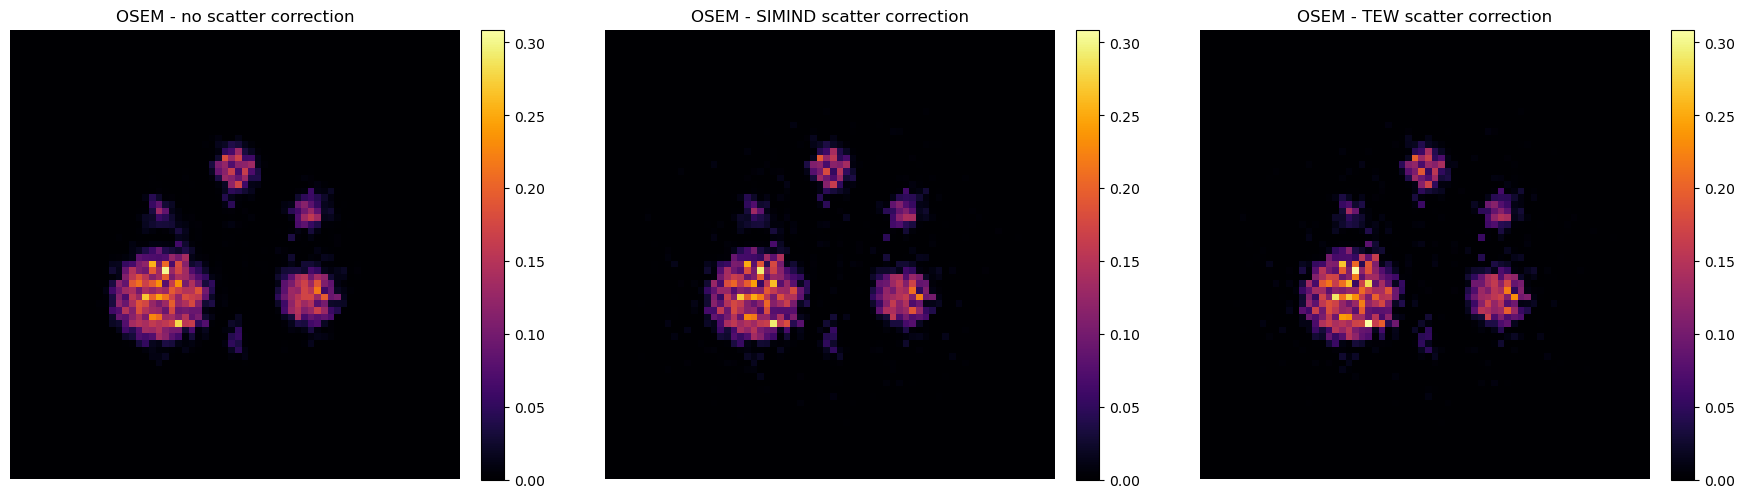

In [25]:
idx = (56, slice(30, 98), slice(30, 98))

recon_arrays = [
    initial_reconstruction.as_array(),
    mc_reconstruction.as_array(),
    tew_reconstruction.as_array(),
]

vmax = max(np.max(arr[idx]) for arr in recon_arrays)

utils.display_arr(
    arr_3d=recon_arrays,
    idx=idx,
    vmax=[vmax] * 3,
    titles=[
        "OSEM - no scatter correction",
        "OSEM - SIMIND scatter correction",
        "OSEM - TEW scatter correction"
    ]
)

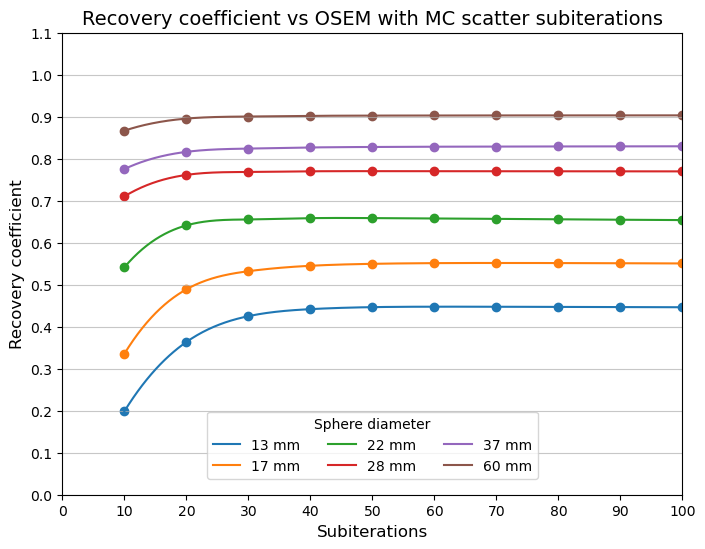

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Lu-177 Ground Truth'}>,
        <Axes: title={'center': 'Lu-177 OSEM MC reconstruction (sub=100)'}>,
        <Axes: title={'center': 'Difference Image'}>], dtype=object))

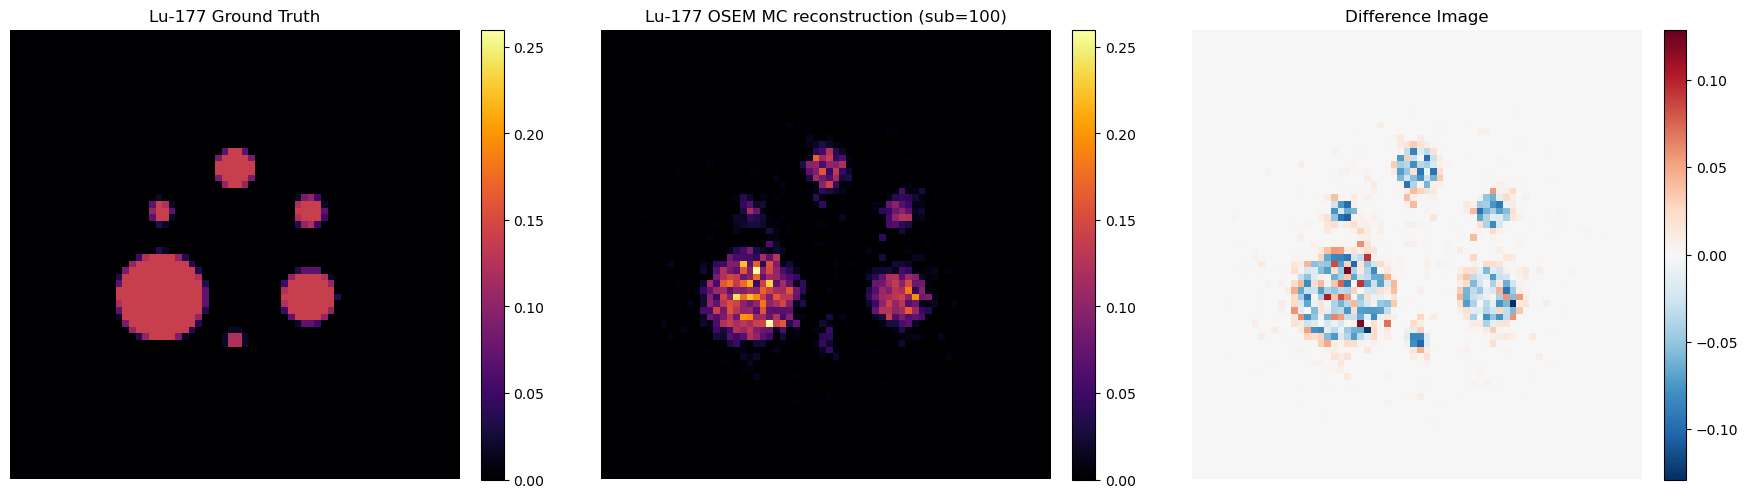

In [26]:
diametre_mm = [13, 17, 22, 28, 37, 60]

recon_prefix = "lu177_mc_recon"

gt_dir = demo1_path / "simind_data" / "lu177_128" / "input"
recon_dir = demo2_path / "mc_scatter" / "recons" / "osem_mc2"

# Load source image
nema_act_arr = spect.ImageData(
    str(gt_dir / "nema_lu_act.hv")
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(gt_dir / "masks_lu.npz")
)

rc_data = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    icf=icf_osem,
    verbose=False
)

utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title=f"Recovery coefficient vs OSEM with MC scatter subiterations",
    ylim=(0,1.1)
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = recon_dict[str(subit)] / icf_osem_mc

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit, recon_subit-nema_act_arr],
    idx=idx,
    vmax=[vmax, vmax, np.max(np.abs(nema_act_arr[idx] - recon_subit[idx]))],
    titles=[f"Lu-177 Ground Truth", 
        f"Lu-177 OSEM MC reconstruction (sub={subit})",
        "Difference Image"
        ],
    cmap=["inferno", "inferno", "RdBu_r"]
)